# Machine Learning Competition

**Name:** Sara AlNajjar  
**Project 3** 

# EDA

## Imports

In [232]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Data

In [233]:
df = pd.read_csv('data.csv')
test = pd.read_csv('test.csv')
df.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3,"1,507 sqft / 140 sqm",6 Aug 2025,Sayed Sadeq Jaafar,Grnata Real Estate,2.0,250.0
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5+ Maid,5,"4,844 sqft / 450 sqm",30 Jul 2025,Zsuzsanna Gecse,Arabian Homes Properties,13.0,1280.0


## 2. Shape & Unique

In [234]:
df.shape , test.shape

((10578, 16), (3527, 15))

In [235]:
df['Beds'].unique()

<ArrowStringArray>
[     '3+ Maid',            '5',       'studio',            '3',
      '5+ Maid',            '2',      '4+ Maid',            '1',
      '2+ Maid',            '4',            '6',      '1+ Maid',
           '7+',      '6+ Maid', 'studio+ Maid',            '0',
     '7++ Maid',            '7',      '7+ Maid']
Length: 19, dtype: str

In [236]:
df['Baths'].unique()

<ArrowStringArray>
['4', '6', '1', '3', '5', '2', '7+', '7', 'none']
Length: 9, dtype: str

In [237]:
df['Agency'].unique()

<ArrowStringArray>
[  'Almoayyed property solutions',          'Al Lagoon Real Estate',
         'Green Line Real Estate',             'Grnata Real Estate',
       'Arabian Homes Properties',       'Jes Property Consultancy',
          'River West Properties',              'Alaska Properties',
             'Al Wrd Real Estate',         'Kensington Real Estate',
 ...
  'High Rise Property Management',                      'Mr. Amran',
                    'Reef Island',                'Kazerooni Group',
      'Y.K. Almoayyed Properties',             'Al Yal Real Estate',
          'Al Zallaq Real Estate',            'Majestic Properties',
                  'Burooj Alsama', 'Circle Point Homes Real Estate']
Length: 206, dtype: str

In [238]:
df['Area'].unique()

<ArrowStringArray>
[         'Amwaj Avenue, Amwaj Islands',
                    'Diyar Al Muharraq',
                           'Al Juffair',
                              'Jidhafs',
                        'Amwaj Islands',
                            'Busaiteen',
                          'Reef Island',
 'Essence of Dilmunia, Dilmunia Island',
                         'Zinj, Manama',
                   'Al Burhama, Manama',
 ...
                             'Al Markh',
            'Mozoon, Diyar Al Muharraq',
              'Bilad Al Qadeem, Manama',
   'Deerat Al Oyoun, Diyar Al Muharraq',
                                    nan,
             'Dareena, Dilmunia Island',
                             'Al Hajar',
                              'Maameer',
                    'Wahat Al Muharraq',
                       'Adhari, Manama']
Length: 128, dtype: str

## 3. Dtypes

In [239]:
df.dtypes

Property_id            int64
Offer                    str
URL                      str
Property_type            str
Include_w_e              str
Title                    str
Area                     str
Governorate              str
Beds                     str
Baths                    str
Size                     str
Availability_date        str
Agent_name               str
Agency                   str
Amenities            float64
rent                 float64
dtype: object

## 4. Drop

In [240]:
drop_cols = ['URL', 'Title', 'Agent_name', 'Agency','Offer']
df = df.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)
df.columns.tolist()

['Property_id',
 'Property_type',
 'Include_w_e',
 'Area',
 'Governorate',
 'Beds',
 'Baths',
 'Size',
 'Availability_date',
 'Amenities',
 'rent']

In [241]:
df.describe()

,Property_id,Amenities,rent
count,10578.000000,10272.000000,10575.000000
mean,7059.734260,10.319996,718.750071
std,4080.910374,5.093414,5318.027519
min,2.000000,1.000000,50.000000
25%,3521.250000,6.000000,330.000000
50%,7023.500000,11.000000,450.000000
75%,10605.750000,14.000000,700.000000
max,14103.000000,25.000000,400000.000000


## 5. Nulls & Fillna

In [242]:
df.isnull().sum()

Property_id            0
Property_type          0
Include_w_e            0
Area                   3
Governorate            3
Beds                   0
Baths                  0
Size                   0
Availability_date    519
Amenities            306
rent                   3
dtype: int64

In [243]:
df['Availability_date'] = pd.to_datetime(df['Availability_date'], errors='coerce')
test['Availability_date'] = pd.to_datetime(test['Availability_date'], errors='coerce')

for blank in (df, test):
    blank['Governorate'] = blank['Governorate'].fillna('Unknown')
    blank['Area'] = blank['Area'].fillna('Unknown')
    blank['Amenities'] = blank['Amenities'].fillna(0)

df = df.dropna(subset=['rent'])
df.isnull().sum()

Property_id            0
Property_type          0
Include_w_e            0
Area                   0
Governorate            0
Beds                   0
Baths                  0
Size                   0
Availability_date    516
Amenities              0
rent                   0
dtype: int64

## 6: Outliers

Removed 127 outlier rows (bounds 0-1810 BHD)


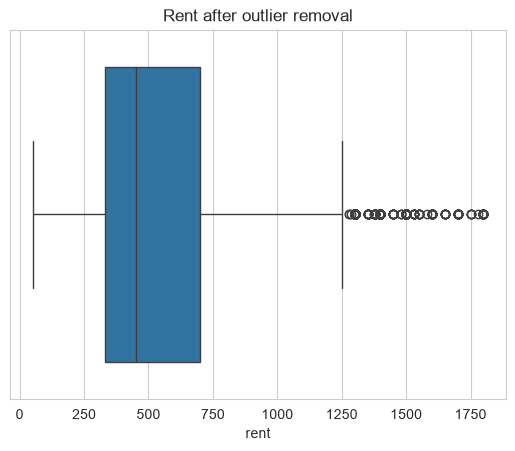

In [244]:
q1, q3 = df['rent'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = max(0, q1 - 3 * iqr), q3 + 3 * iqr

before = len(df)
df = df[(df['rent'] >= lower) & (df['rent'] <= upper)]
print(f'Removed {before - len(df)} outlier rows (bounds {lower:.0f}-{upper:.0f} BHD)')

sns.boxplot(x=df['rent'])
plt.title('Rent after outlier removal')
plt.show()

In [245]:
df.describe()

,Property_id,Availability_date,Amenities,rent
count,10448.000000,9940,10448.000000,10448.000000
mean,7056.085949,2025-06-23 08:20:31.388330,9.999234,550.883614
min,2.000000,2005-03-16 00:00:00,0.000000,50.000000
25%,3515.500000,2025-06-17 00:00:00,6.000000,330.000000
50%,7012.500000,2025-08-17 00:00:00,10.000000,450.000000
75%,10605.250000,2025-09-11 00:00:00,14.000000,700.000000
max,14103.000000,2026-03-01 00:00:00,25.000000,1800.000000
std,4081.813770,NaN,5.303158,324.021800


## 7. Rename

In [246]:
df = df.rename(columns={'Include_w_e': 'Utilities_Included'})
test = test.rename(columns={'Include_w_e': 'Utilities_Included'})
df.columns.tolist()

['Property_id',
 'Property_type',
 'Utilities_Included',
 'Area',
 'Governorate',
 'Beds',
 'Baths',
 'Size',
 'Availability_date',
 'Amenities',
 'rent']

In [247]:
df.head()

,Property_id,Property_type,Utilities_Included,Area,Governorate,Beds,Baths,Size,Availability_date,Amenities,rent
0,6046,Villa,Inclusive,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",2025-04-09,6.0,1000.0
1,2240,Villa,Exclusive,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",2025-09-16,5.0,700.0
2,6248,Apartment,Inclusive,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,2025-08-17,12.0,260.0
3,7177,Apartment,Exclusive,Jidhafs,Northern Governorate,3,3,"1,507 sqft / 140 sqm",2025-08-06,2.0,250.0
4,7842,Villa,Exclusive,Al Juffair,Capital Governorate,5+ Maid,5,"4,844 sqft / 450 sqm",2025-07-30,13.0,1280.0


## 8. Duplicates

In [248]:
print('Duplicates:', df.duplicated().sum())
df = df.drop_duplicates()
df.shape

Duplicates: 0


(10448, 11)

## 9. Describe 

In [249]:
df.describe()

,Property_id,Availability_date,Amenities,rent
count,10448.000000,9940,10448.000000,10448.000000
mean,7056.085949,2025-06-23 08:20:31.388330,9.999234,550.883614
min,2.000000,2005-03-16 00:00:00,0.000000,50.000000
25%,3515.500000,2025-06-17 00:00:00,6.000000,330.000000
50%,7012.500000,2025-08-17 00:00:00,10.000000,450.000000
75%,10605.250000,2025-09-11 00:00:00,14.000000,700.000000
max,14103.000000,2026-03-01 00:00:00,25.000000,1800.000000
std,4081.813770,NaN,5.303158,324.021800


## 9. Value counts

In [250]:
for col in ['Property_type', 'Utilities_Included', 'Governorate']:
    print(df[col].value_counts(), '\n')

Property_type
Apartment                       8342
Villa                           1785
Compound                         131
Duplex                            95
Penthouse                         59
Townhouse                         21
Hotel Apartment                    6
Whole Building                     6
Bulk Rent Unit                     1
Short Term & Hotel Apartment       1
Bungalow                           1
Name: count, dtype: int64 

Utilities_Included
Inclusive    6429
Exclusive    4019
Name: count, dtype: int64 

Governorate
Capital Governorate     5249
Muharraq Governorate    2817
Northern Governorate    1837
Central Governorate      311
Southern Governorate     234
Name: count, dtype: int64 



## 10. Casting
- `Beds` → `Beds_num` + binary `Has_maid_room`
- `Baths` → `Baths_num`
- `Size` → `Size_sqft` / `Size_sqm`

In [251]:
for frame in (df, test):
    frame['Has_maid_room'] = frame['Beds'].astype(str).str.lower().str.contains('maid').astype(int)
    frame['Beds_num'] = (
        frame['Beds'].astype(str)
        .str.replace('++', '+', regex=False)
        .str.replace('Maid', '', regex=False)
        .str.replace('+ ', '', regex=False)
        .str.replace('+', '', regex=False)
        .str.replace('studio', '0', regex=False)
        .str.strip()
    )
    frame['Beds_num'] = pd.to_numeric(frame['Beds_num'], errors='coerce')

df['Has_maid_room'].value_counts()

Has_maid_room
0    8311
1    2137
Name: count, dtype: int64

In [252]:
df['Beds_num'].unique()

array([3, 5, 0, 2, 4, 1, 6, 7])

## 11. Parsing

In [253]:
def parse_baths(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == 'none':
        return 0
    try:
        return float(x.replace('+', ''))
    except ValueError:
        return np.nan

def parse_size(x):
    m = re.findall(r'([\d,]+)\s*sqft\s*/\s*([\d,]+)\s*sqm', str(x))
    if not m:
        return np.nan, np.nan
    sqft, sqm = m[0]
    return float(sqft.replace(',', '')), float(sqm.replace(',', ''))

for frame in (df, test):
    frame['Baths_num'] = frame['Baths'].apply(parse_baths)
    size = frame['Size'].apply(parse_size)
    frame['Size_sqft'] = size.apply(lambda t: t[0])
    frame['Size_sqm'] = size.apply(lambda t: t[1])
    frame.drop(columns=['Beds', 'Baths', 'Size', 'Availability_date'], inplace=True)

for col in ['Beds_num', 'Baths_num']:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    test[col] = test[col].fillna(med)

df.dtypes

Property_id             int64
Property_type             str
Utilities_Included        str
Area                      str
Governorate               str
Amenities             float64
rent                  float64
Has_maid_room           int64
Beds_num                int64
Baths_num             float64
Size_sqft             float64
Size_sqm              float64
dtype: object

# Pre Processing

## 1: Corr

In [254]:
num_cols_check = ['rent', 'Beds_num', 'Baths_num', 'Size_sqft', 'Size_sqm', 'Amenities', 'Has_maid_room', 'Days_to_available']
sns.heatmap(df[num_cols_check].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

KeyError: "['Days_to_available'] not in index"

## 2. Dummies

In [255]:
pd.get_dummies(df['Property_type'], prefix='Property_type').head()

,Property_type_Apartment,Property_type_Bulk Rent Unit,Property_type_Bungalow,Property_type_Compound,Property_type_Duplex,Property_type_Hotel Apartment,Property_type_Penthouse,Property_type_Short Term & Hotel Apartment,Property_type_Townhouse,Property_type_Villa,Property_type_Whole Building
0,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,True,False
2,True,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False


## 3. Crosstab

In [256]:
pd.crosstab(df['Governorate'], df['Property_type'])

Property_type,Apartment,Bulk Rent Unit,Bungalow,Compound,Duplex,Hotel Apartment,Penthouse,Short Term & Hotel Apartment,Townhouse,Villa,Whole Building
Governorate,,,,,,,,,,,
Capital Governorate,4879,0,0,9,64,4,25,0,2,265,1
Central Governorate,207,0,0,5,1,0,2,0,1,93,2
Muharraq Governorate,2411,1,0,3,27,2,32,0,7,332,2
Northern Governorate,710,0,1,114,1,0,0,1,6,1003,1
Southern Governorate,135,0,0,0,2,0,0,0,5,92,0


## 4. Plot

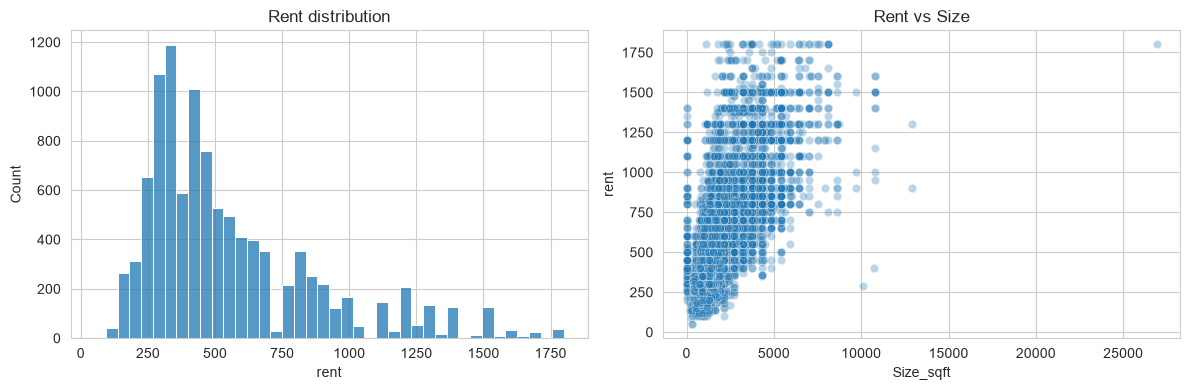

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['rent'], bins=40, ax=axes[0]).set_title('Rent distribution')
sns.scatterplot(x='Size_sqft', y='rent', data=df, alpha=0.3, ax=axes[1]).set_title('Rent vs Size')
plt.tight_layout()
plt.show()

## 5. Feature and target 

In [137]:
target = 'rent'
X = df.drop(columns=['Property_id', target])
y = df[target]

X_test_final = test.drop(columns=['Property_id'])
test_ids = test['Property_id']

## 6. Skew

In [138]:
y_log = np.log1p(y)
X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)
X_train.shape, X_val.shape

((8358, 11), (2090, 11))

## 7. Col grouping

In [139]:
cat_cols = ['Property_type', 'Utilities_Included', 'Area', 'Governorate']
skew_cols = ['Size_sqft', 'Size_sqm']
factor_cols = ['Beds_num', 'Has_maid_room', 'Baths_num', 'Amenities', 'Days_to_available']

## 8. Cat

In [140]:
X_train[cat_cols].nunique()

Property_type          10
Utilities_Included      2
Area                  126
Governorate             5
dtype: int64

## 9. Num

In [141]:
X_train[skew_cols + factor_cols].describe()

,Size_sqft,Size_sqm,Beds_num,Has_maid_room,Baths_num,Amenities,Days_to_available
count,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000
mean,1772.357023,164.656616,2.176837,0.206868,2.628021,10.027040,176.513999
std,1392.878702,129.401297,1.179713,0.405084,1.253284,5.287837,180.471527
min,11.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-3745.000000
25%,969.000000,90.000000,1.000000,0.000000,2.000000,6.000000,172.000000
50%,1335.000000,124.000000,2.000000,0.000000,2.000000,10.000000,228.000000
75%,1938.000000,180.000000,3.000000,0.000000,3.000000,14.000000,252.000000
max,26910.000000,2500.000000,7.000000,1.000000,7.000000,25.000000,424.000000


## 10. Concat

In [142]:
X_train_num = X_train[skew_cols + factor_cols].fillna(X_train[skew_cols + factor_cols].median())
X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_train_manual = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_train_manual.shape

(8358, 146)

## 11. StandardScaler

In [143]:
scaler = StandardScaler()
X_train_manual[skew_cols + factor_cols] = scaler.fit_transform(X_train_manual[skew_cols + factor_cols])
X_train_manual.head()

,Size_sqft,Size_sqm,Beds_num,Has_maid_room,Baths_num,Amenities,Days_to_available,Property_type_Bulk Rent Unit,Property_type_Compound,Property_type_Duplex,Property_type_Hotel Apartment,Property_type_Penthouse,Property_type_Short Term & Hotel Apartment,Property_type_Townhouse,Property_type_Villa,Property_type_Whole Building,Utilities_Included_Inclusive,"Area_Abraj Al Lulu, Manama","Area_Address Marassi Vista, Diyar Al Muharraq","Area_Adhari, Manama","Area_Adliya, Manama","Area_Al Areen Development, Zallaq","Area_Al Bahair, Riffa","Area_Al Burhama, Manama",Area_Al Dair,Area_Al Hajar,Area_Al Jasra,Area_Al Juffair,Area_Al Maqsha,Area_Al Markh,"Area_Al Marsa Floating City, Amwaj Islands","Area_Al Naseem, Diyar Al Muharraq","Area_Al Noor, Diyar Al Muharraq",Area_Al Qadam,Area_Al Qurayyah,"Area_Al Sherooq, Diyar Al Muharraq","Area_Al Sidra, Diyar Al Muharraq","Area_Al Thurya villa Diyar Al Muharraq, Diyar Al Muharraq","Area_Alhajiyat, Riffa","Area_Amwaj Avenue, Amwaj Islands","Area_Amwaj Beachfront, Amwaj Islands","Area_Amwaj Homes, Amwaj Islands",Area_Amwaj Islands,"Area_Amwaj Marina, Amwaj Islands",Area_Arad,Area_Askar,Area_Bahrain Bay,"Area_Bahrain Financial Harbour, Manama",Area_Bani Jamra,Area_Barbar,"Area_Bilad Al Qadeem, Manama","Area_Breeze of Dilmunia, Dilmunia Island",Area_Bu Ashira,"Area_Bu Ghazal, Manama","Area_Bu Kowarah, Riffa",Area_Bu Quwah,Area_Budaiya,Area_Buri,Area_Busaiteen,"Area_Canal View, Dilmunia Island","Area_Dareena, Dilmunia Island","Area_Deerat Al Oyoun, Diyar Al Muharraq",Area_Dilmunia Island,"Area_Diplomatic Area, Manama",Area_Diraz,Area_Diyar Al Muharraq,Area_Durrat Al Bahrain,"Area_Durrat Marina, Durrat Al Bahrain",Area_Eker,"Area_Essence of Dilmunia, Dilmunia Island","Area_Exhibition Road, Hoora",Area_Galali,"Area_Ghuraifah (Old Juffair), Manama","Area_Gudaibiya, Manama","Area_Gufool, Manama",Area_Hamad Town,Area_Hamala,"Area_Hanging Garden, Dilmunia Island",Area_Hidd,Area_Hoora,Area_Isa Town,Area_Janabiya,Area_Jannusan,Area_Jeblat Hebshi,Area_Jid Ali,Area_Jidhafs,Area_Jurdab,"Area_Karbabad, Manama",Area_Maameer,"Area_Mahooz, Manama",Area_Malkiyah,Area_Manama,"Area_Manama Downtown, Manama","Area_Manama Sea Front, Manama","Area_Manama Souq, Manama",Area_Maqabah,"Area_Marassi Al Bahrain, Diyar Al Muharraq","Area_Marassi Boulevard, Diyar Al Muharraq","Area_Marassi Park Residences, Diyar Al Muharraq","Area_Marassi Residences, Diyar Al Muharraq","Area_Marassi Shores Residences, Diyar Al Muharraq","Area_Mozoon, Diyar Al Muharraq",Area_Muharraq,"Area_Murjan 1 (Phase 1 and 2), Durrat Al Bahrain","Area_Murjan, Amwaj Islands",Area_Nabih Saleh,"Area_Najma, Amwaj Islands","Area_North Riffa, Riffa",Area_Northern City (Madinat Salman),Area_Nuwaidrat,"Area_Ras Rumman, Manama",Area_Reef Island,Area_Riffa,"Area_Riffa Al Sharqi, Riffa","Area_Riffa Views, Riffa",Area_Saar,Area_Sadad,Area_Salmabad,"Area_Salmaniya, Manama",Area_Samaheej,"Area_Sanabis, Manama",Area_Sanad,"Area_Saraya 2, Bu Quwah","Area_Saraya al Bahar, Amwaj Islands",Area_Seef,"Area_Segaya, Manama",Area_Sehla,Area_Shakhura,Area_Sitra,"Area_Tala Island, Amwaj Islands",Area_Tashan,"Area_The Address Residences, Diyar Al Muharraq","Area_The Lagoon, Amwaj Islands","Area_The Treasure, Dilmunia Island",Area_Tubli,"Area_Um Al Hasam, Manama",Area_Wahat Al Muharraq,"Area_Water Garden City, Manama","Area_West Riffa, Riffa",Area_Zallaq,"Area_Zinj, Manama","Area_alnaim, Manama",Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate
0,-0.831678,-0.832009,-0.997621,-0.510709,-1.299082,-0.761612,0.013776,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

## 12. Fit

In [144]:
for name, model in {'LinearRegression': LinearRegression(),
                     'Lasso': Lasso(alpha=0.001, max_iter=20000),
                     'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000)}.items():
    model.fit(X_train_manual, y_train)
    print(f'{name}: train R2 = {r2_score(y_train, model.predict(X_train_manual)):.4f}')

LinearRegression: train R2 = 0.7937
Lasso: train R2 = 0.7561
ElasticNet: train R2 = 0.7688


## 13. Cols trans (skew, cat, factor)

In [145]:
cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
skew_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')), ('scale', StandardScaler())])
factor_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])

# Modeling

## 1. Master pipe

In [146]:
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('skew', skew_pipe, skew_cols),
    ('factor', factor_pipe, factor_cols),
])

def build_pipe(model):
    return Pipeline([('prep', preprocessor), ('model', model)]).fit(X_train, y_train)

lr_pipe = build_pipe(LinearRegression())

## 2. R2 Score

In [147]:
def r2(pipe, Xv=X_val, yv=y_val):
    pred = np.expm1(pipe.predict(Xv))
    return r2_score(np.expm1(yv), pred), pred

r2_lr, pred_lr = r2(lr_pipe)
print('LinearRegression R2:', round(r2_lr, 4))

LinearRegression R2: 0.7648


## 3. RMSE

In [148]:
rmse_lr = np.sqrt(mean_squared_error(np.expm1(y_val), pred_lr))
print('LinearRegression RMSE:', round(rmse_lr, 2), 'BHD')

LinearRegression RMSE: 157.41 BHD


## 4. Grid Search

In [150]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_grid = GridSearchCV(Pipeline([('prep', preprocessor), ('model', Lasso(max_iter=20000))]),
                           param_grid={'model__alpha': [0.001, 0.01, 0.1]}, cv=kf).fit(X_train, y_train)

enet_grid = GridSearchCV(Pipeline([('prep', preprocessor), ('model', ElasticNet(max_iter=20000))]),
                          param_grid={'model__alpha': [0.001, 0.01, 0.1], 'model__l1_ratio': [0.1, 0.5, 0.9]},
                          cv=kf).fit(X_train, y_train)

## 5. Fold

In [151]:
kf.get_n_splits()

5

## 6. Best alpha

In [152]:
print('Best Lasso alpha:', lasso_grid.best_params_['model__alpha'])
print('Best ElasticNet alpha:', enet_grid.best_params_['model__alpha'])

Best Lasso alpha: 0.001
Best ElasticNet alpha: 0.001


## 7. L1 Ratio

In [153]:
print('Best ElasticNet l1_ratio:', enet_grid.best_params_['model__l1_ratio'])

Best ElasticNet l1_ratio: 0.1


## 8. Graphs

Best model: LinearRegression - R2 = 0.7648


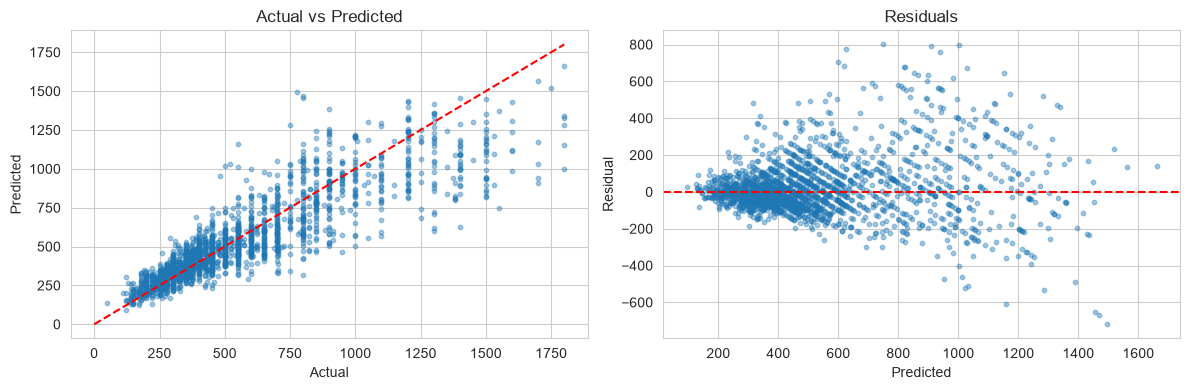

In [154]:
r2_lasso, pred_lasso = r2(lasso_grid.best_estimator_)
r2_enet, pred_enet = r2(enet_grid.best_estimator_)

results = {'LinearRegression': (r2_lr, lr_pipe, pred_lr), 'Lasso': (r2_lasso, lasso_grid.best_estimator_, pred_lasso),
           'ElasticNet': (r2_enet, enet_grid.best_estimator_, pred_enet)}
best_name = max(results, key=lambda k: results[k][0])
best_r2, best_pipe, best_pred = results[best_name]
print('Best model:', best_name, '- R2 =', round(best_r2, 4))

true_val = np.expm1(y_val)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(true_val, best_pred, alpha=0.4, s=10)
axes[0].plot([0, true_val.max()], [0, true_val.max()], 'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Actual vs Predicted')

resid = true_val - best_pred
axes[1].scatter(best_pred, resid, alpha=0.4, s=10)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual'); axes[1].set_title('Residuals')
plt.tight_layout()
plt.show()

## 9. Int & Coeff

In [155]:
best_pipe.fit(X, y_log)
print('Intercept:', best_pipe.named_steps['model'].intercept_)

Intercept: 6.055153954069907


In [156]:
coef_df = pd.DataFrame({'feature': best_pipe.named_steps['prep'].get_feature_names_out(),
                         'coef': best_pipe.named_steps['model'].coef_})
coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(15)

,feature,coef
145,skew__Size_sqm,1.932036
144,skew__Size_sqft,-1.822901
1,cat__Property_type_Bulk Rent Unit,-1.236311
85,cat__Area_Maameer,-0.982128
21,cat__Area_Al Dair,-0.916803
128,"cat__Area_The Address Residences, Diyar Al Muh...",0.824697
15,"cat__Area_Address Marassi Vista, Diyar Al Muha...",0.748546
99,cat__Area_Muharraq,-0.657346
43,cat__Area_Bahrain Bay,0.580316
2,cat__Property_type_Bungalow,0.575345


### Save

In [157]:
test_pred = np.clip(np.expm1(best_pipe.predict(X_test_final)), 50, None)
submission = pd.DataFrame({'Property_id': test_ids, 'rent': test_pred})
submission.to_csv('submission.csv', index=False)
submission.head()

,Property_id,rent
0,4394,406.456206
1,2338,445.528549
2,8531,766.665153
3,8952,350.686095
4,11064,259.148137
